In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
#!pip install ultralytics

from ultralytics import YOLO
from PIL import Image
import numpy as np
import pandas as pd
import tensorflow as tf

E0000 00:00:1781122584.962073    1265 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781122584.971733    1265 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781122584.995279    1265 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781122584.995311    1265 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781122584.995314    1265 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781122584.995317    1265 computation_placer.cc:177] computation placer already registered. Please check linka

In [3]:
df = pd.read_csv('/kaggle/input/datasets/marquis03/cats-and-dogs/train.csv')

In [4]:
df.sample()

,image:FILE,category
77,train/cat/Abyssinian_127_jpg.rf.b2553880d73a78...,0


In [5]:
base_line = '/kaggle/input/datasets/marquis03/cats-and-dogs/'
df['base_file'] = base_line + df['image:FILE']
df.sample(3)

,image:FILE,category,base_file
183,train/dog/american_bulldog_169_jpg.rf.63d3bbe9...,1,/kaggle/input/datasets/marquis03/cats-and-dogs...
265,train/dog/wheaten_terrier_188_jpg.rf.c42d67cec...,1,/kaggle/input/datasets/marquis03/cats-and-dogs...
89,train/cat/Persian_143_jpg.rf.cef1519ca541c5e4f...,0,/kaggle/input/datasets/marquis03/cats-and-dogs...


In [6]:
df.drop(columns=['image:FILE'],axis=1,inplace=True)
df.sample()

,category,base_file
197,1,/kaggle/input/datasets/marquis03/cats-and-dogs...


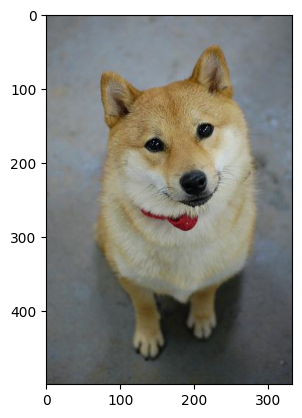

In [10]:
import matplotlib.pyplot as plt
img = Image.open(df.iloc[159]['base_file'])
plt.imshow(img)

In [11]:
file_path = df.iloc[159]['base_file']

model = YOLO('yolov8n.pt')

results = model(file_path)


image 1/1 /kaggle/input/datasets/marquis03/cats-and-dogs/train/dog/shiba_inu_165_jpg.rf.4354dc9a1f76107c29b0e0528e781980.jpg: 640x448 1 dog, 8.3ms
Speed: 3.8ms preprocess, 8.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 448)


In [12]:
result = results[0]

boxes = result.boxes

names = model.names

names[int(boxes.cls[0])]

'dog'

In [13]:
results[0].save('output_img2.jpg')

'output_img2.jpg'

In [ ]:
img1 = Image.open('/kaggle/working/output_img2.jpg')
im
                  